# Fagprojekt

In [1]:
from pathlib import Path
import os

import numpy as np
import vedo
from vedo import settings
from PIL import Image
from skimage.measure import label, regionprops

from skimage import io
from skimage.filters import threshold_multiotsu

import torch
from transformers import AutoImageProcessor, AutoModel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from scipy import ndimage
from sklearn.metrics.pairwise import cosine_similarity
import math

from dataclasses import asdict, dataclass
from pathlib import Path
import json
import argparse
from PIL import Image, ImageDraw
from vtkmodules.vtkRenderingCore import vtkCoordinate
import tempfile

from types import SimpleNamespace
import tifffile

settings.default_backend = "vtk"

c:\Users\Bruger\miniconda3\envs\dinov2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
VIEWS = [
    ("1", "+X", np.array([1, 0, 0]), np.array([0, 0, 1])),
    ("2", "-X", np.array([-1, 0, 0]), np.array([0, 0, 1])),
    ("3", "+Y", np.array([0, 1, 0]), np.array([0, 0, 1])),
    ("4", "-Y", np.array([0, -1, 0]), np.array([0, 0, 1])),
    ("5", "+Z", np.array([0, 0, 1]), np.array([0, 1, 0])),
    ("6", "-Z", np.array([0, 0, -1]), np.array([0, 1, 0])),]

ANGLE_TO_INDEX = {
    "+X": 1,
    "-X": 2,
    "+Y": 3,
    "-Y": 4,
    "+Z": 5,
    "-Z": 6,
}

angles = ["+X", "-X", "+Y", "-Y", "+Z", "-Z"]

animals = ["BC", "BF", "BL", "BP", "CF", "GH", "MA", "PP", "WO"]

## Part 1 - Computer grafik

In [3]:
zoom = 1.2
render_size = (980,980)

In [4]:
# @dataclass
# class SegmentationConfig:
#     threshold_percentile: float = 97.5
#     zoom: float = 1.2
#     render_size: tuple[int, int] = (980, 980)

In [5]:
@dataclass
class RenderConfig:
    threshold_percentile: float = 97.5
    zoom: float = 1.2
    render_size: tuple[int, int] = (980, 980)
    patch_size: int = 14
    patch_color: tuple[int, int, int] = (0, 180, 0)
    patch_width: int = 3

    @classmethod
    def from_metadata(
        cls,
        metadata_path: Path,
        patch_size_override: int | None = None,
    ) -> "RenderConfig":
        meta = json.loads(metadata_path.read_text(encoding="utf-8"))
        cfg = meta.get("config", {})

        render_size = cfg.get("render_size", [980, 980])
        if not isinstance(render_size, list) or len(render_size) != 2:
            render_size = [980, 980]

        patch_size = patch_size_override if patch_size_override is not None else 14
        return cls(
            threshold_percentile=float(cfg.get("threshold_percentile", 97.5)),
            zoom=float(cfg.get("zoom", 1.2)),
            render_size=(int(render_size[0]), int(render_size[1])),
            patch_size=int(patch_size),
        )

In [6]:
def find_input_volumes(in_root: Path) -> list[Path]:
    return sorted(p for p in in_root.rglob("*.tif"))

In [ ]:
def segment_largest_component(volume: np.ndarray) -> np.ndarray:
    thresholds = threshold_multiotsu(volume,classes=2)

    regions = np.digitize(volume,bins=thresholds)

    mask = regions == 2

    mask = ndimage.binary_dilation(mask,iterations=5)
    mask = ndimage.binary_fill_holes(mask)

    labeled, num = ndimage.label(mask)

    sizes = ndimage.sum_labels(volume, labeled, index=np.arange(1, num + 1))
    largest = int(np.argmax(sizes) + 1)

    mask = labeled == largest

    # returns mask of largest component, weighted by intensity
    return mask

In [8]:
def render_views(
    clean_volume: np.ndarray,
    out_dir: Path,
    base_name: str,
) -> dict[str, object]:
    vol = vedo.Volume(clean_volume)
    xmin, xmax, ymin, ymax, zmin, zmax = vol.bounds()
    center = np.array([(xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2], dtype=float)
    diag = np.linalg.norm([xmax - xmin, ymax - ymin, zmax - zmin])
    distance = max(diag * 1.5, 1.0)
    camera_views: list[dict[str, object]] = []

    plotter = vedo.Plotter(size=render_size, offscreen=True, bg="white")
    try:
        for idx, label, direction, view_up in VIEWS:
            plotter.clear()
            plotter.show(vol, resetcam=True, zoom=zoom)

            cam = plotter.camera
            cam.SetFocalPoint(*center)
            cam.SetPosition(*(center + direction * distance))
            cam.SetViewUp(*view_up)
            plotter.renderer.ResetCameraClippingRange()

            out_path = out_dir / f"{base_name}_{idx}_{label}.png"
            plotter.screenshot(str(out_path))
            cam_pos = (center + direction * distance).tolist()
            camera_views.append(
                {
                    "view_index": int(idx),
                    "angle": label,
                    "direction": direction.astype(float).tolist(),
                    "view_up": view_up.astype(float).tolist(),
                    "camera_position": cam_pos,
                    "camera_focal_point": center.astype(float).tolist(),
                    "output_image": str(out_path),
                }
            )
    finally:
        plotter.close()

    return {
        "bounds_xyzxyz": [float(xmin), float(xmax), float(ymin), float(ymax), float(zmin), float(zmax)],
        "volume_center_xyz": center.astype(float).tolist(),
        "camera_distance": float(distance),
        "camera_views": camera_views,
    }

In [9]:
def process_volume(in_path: Path, in_root: Path, out_root: Path) -> Path:
    rel_parent = in_path.parent.relative_to(in_root)
    out_dir = out_root / rel_parent / in_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    data = vedo.load(str(in_path)).tonumpy()
    mask = segment_largest_component(data)

    clean_data = np.zeros_like(data)
    clean_data[mask] = data[mask]
    render_meta = render_views(clean_data, out_dir=out_dir, base_name=in_path.stem)

    # Voxel axis convention for numpy volume arrays from vedo in this project: [x, y, z].
    shape_xyz = [int(data.shape[0]), int(data.shape[1]), int(data.shape[2])]
    shape_zyx = [shape_xyz[2], shape_xyz[1], shape_xyz[0]]

    metadata = {
        "source_path": str(in_path),
        "output_dir": str(out_dir),
        "volume_shape": shape_xyz,  # Backward-compatible alias; treat as xyz.
        "volume_shape_zyx": shape_zyx,
        "volume_shape_xyz": shape_xyz,
        "voxel_axis_order": "xyz",
        "kept_voxels": int(mask.sum()),
        "total_voxels": int(mask.size),
        "mask_fill_ratio": float(mask.sum() / max(mask.size, 1)),
        "render_geometry": render_meta,
    }
    (out_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return out_dir

In [15]:
input_root = Path("data/original_photos")
output_root = Path("data/Photos")

volumes = find_input_volumes(input_root)

In [16]:
volumes[11*0]

WindowsPath('data/original_photos/AC/bcrick_1_000.tif')

In [17]:
in_path, in_root, out_root = volumes[11*3], input_root, output_root

volume = vedo.load(in_path).tonumpy()

In [18]:
in_path, in_root, out_root = volumes[11*3], input_root, output_root

volume = vedo.load(in_path).tonumpy()

mask = segment_largest_component(volume)

clean_data = np.zeros_like(volume)
clean_data[mask] = volume[mask]

vol = vedo.Volume(clean_data)
xmin, xmax, ymin, ymax, zmin, zmax = vol.bounds()
center = np.array([(xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2], dtype=float)
diag = np.linalg.norm([xmax - xmin, ymax - ymin, zmax - zmin])
distance = max(diag * 1.1, 1.0)
camera_views: list[dict[str, object]] = []

plotter = vedo.Plotter(size=render_size, offscreen=True, bg="white")

rel_parent = in_path.parent.relative_to(in_root)
out_dir = out_root / rel_parent / in_path.stem
out_dir.mkdir(parents=True, exist_ok=True)
base_name=in_path.stem

for idx, label, direction, view_up in VIEWS:
    plotter.clear()
    plotter.show(vol, resetcam=True, zoom=zoom)

    cam = plotter.camera
    cam.SetFocalPoint(*center)
    cam.SetPosition(*(center + direction * distance))
    cam.SetViewUp(*view_up)
    plotter.renderer.ResetCameraClippingRange()

    out_path = out_dir / f"{rel_parent}_segmentation_part4_{idx}.png"
    plotter.screenshot(str(out_path))

ValueError: attempt to get argmax of an empty sequence

In [ ]:
in_path, in_root, out_root = volumes[11*3], input_root, output_root

volume = (vedo.load(in_path).tonumpy()).ravel()

array([71])

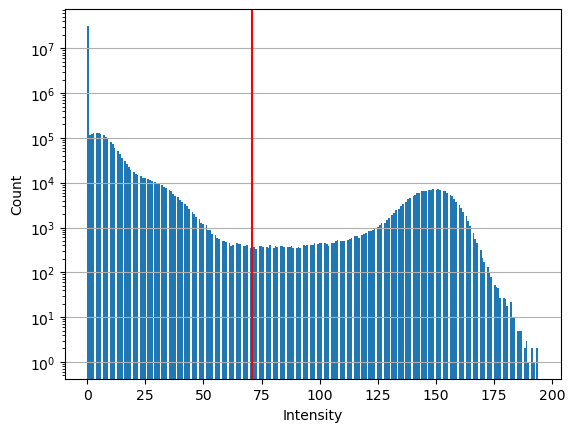

In [ ]:
thresholds = threshold_multiotsu(volume, classes=2)

plt.hist(volume, bins=255, log=True)
for thresh in thresholds:
    plt.axvline(thresh, color='r')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.grid(axis='y')
thresholds

array([12, 83])

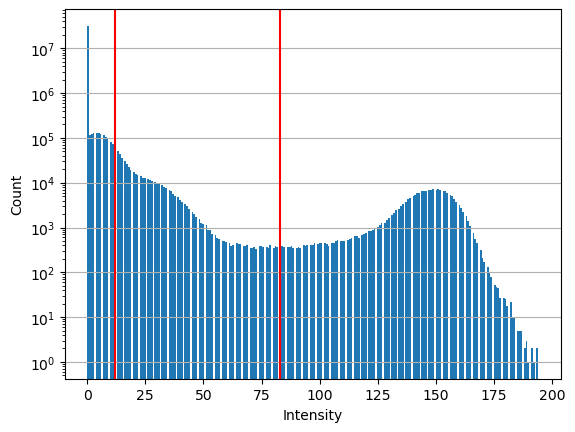

In [ ]:
thresholds = threshold_multiotsu(volume, classes=3)

plt.hist(volume, bins=255, log=True)
for thresh in thresholds:
    plt.axvline(thresh, color='r')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.grid(axis='y')
thresholds

In [ ]:
process_volume(volumes[11*2], input_root, output_root)

In [ ]:
for i, f in enumerate(volumes[3::11] + volumes[5::11] + volumes[7::11]):
    print(f"Processing {i+1}/{len(volumes)}:", f.name)
    process_volume(f, input_root, output_root)

Processing 1/132: bcrick_1_003.tif
Processing 2/132: sfaar_1_003.tif
Processing 3/132: spy_1_003.tif
Processing 4/132: boffel_1_003.tif
Processing 5/132: guld_1_003.tif
Processing 6/132: krol_1_003.tif
Processing 7/132: gras_1_003.tif
Processing 8/132: maddi_1_003.tif
Processing 9/132: mel_1_003.tif
Processing 10/132: fluepup_1_003.tif
Processing 11/132: soldat_1_003.tif
Processing 12/132: bank_1_003.tif
Processing 13/132: bcrick_1_005.tif
Processing 14/132: sfaar_1_005.tif
Processing 15/132: spy_1_005.tif
Processing 16/132: boffel_1_005.tif
Processing 17/132: guld_1_005.tif
Processing 18/132: krol_1_005.tif
Processing 19/132: gras_1_005.tif
Processing 20/132: maddi_1_005.tif
Processing 21/132: mel_1_005.tif
Processing 22/132: fluepup_1_005.tif
Processing 23/132: soldat_1_005.tif
Processing 24/132: bank_1_005.tif
Processing 25/132: bcrick_1_007.tif
Processing 26/132: sfaar_1_007.tif
Processing 27/132: spy_1_007.tif
Processing 28/132: boffel_1_007.tif
Processing 29/132: guld_1_007.tif
P

In [ ]:
def log(message: str) -> None:
    print(message, flush=True)

In [ ]:
model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
log(f"Starting top3 head patch run | model={model_name} | device={device}")
log("Loading DINO processor...")
processor = AutoImageProcessor.from_pretrained(model_name)
log("Loading DINO model...")
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()
log("Model loaded.")
patch_size = int(getattr(model.config, "patch_size", 16))
num_register_tokens = int(getattr(model.config, "num_register_tokens", 0))
num_prefix_tokens = 1 + num_register_tokens  # CLS + register tokens
log(f"patch_size={patch_size} | num_register_tokens={num_register_tokens}")

Starting top3 head patch run | model=facebook/dinov3-vits16-pretrain-lvd1689m | device=cpu
Loading DINO processor...


preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

c:\Users\madsl\Miniconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\madsl\.cache\huggingface\hub\models--facebook--dinov3-vits16-pretrain-lvd1689m. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading DINO model...


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Model loaded.
patch_size=16 | num_register_tokens=4
